# **Lab 7 REPORT _____ BOUHOUIA Yousra G1**

# Lab: U-Net for Semantic Segmentation and Efficient Fine-Tuning

In this lab, we study **semantic segmentation** using U-Net. Semantic segmentation is the task of assigning a class label to each pixel in an image.

Instead of only predicting whether an object exists, a segmentation model predicts **where the object is at pixel level**.

<img src="Figs/segmentEx.png" style="width:950px;">

## Lab objectives

By the end of this lab, you should be able to:

1. Load and visualize a segmentation dataset.
2. Prepare binary masks for semantic segmentation.
3. Use a U-Net model with a pretrained encoder.
4. Evaluate segmentation using Dice, IoU, and pixel accuracy.
5. Fine-tune the full U-Net network.
6. Fine-tune only the decoder and segmentation head.
7. Compare both fine-tuning strategies in terms of performance and training cost.

## Dataset

We use the Penn-Fudan Pedestrian dataset. The task is binary segmentation.

## Main experiment

We compare two strategies:

1. **Full-network fine-tuning**: update the encoder, decoder, and segmentation head.
2. **Decoder-only fine-tuning**: freeze the pretrained encoder and update only the decoder and segmentation head.

## Deliverable

At the end of the lab, you must submit:

> the completed and executed notebook.

Your notebook must include:

- all completed `TODO` sections;
- all executed cells with outputs visible;
- training curves or logged metrics;
- final Dice, IoU, and pixel accuracy scores;
- predicted masks visualized on validation images;
- written answers to the analysis questions.


## 1. Install and import required libraries

The notebook is designed to run on a standard machine without requiring a GPU. If a GPU is available, PyTorch will use it automatically.

In [23]:
import importlib.util
import subprocess
import sys


def ensure_package(import_name, pip_name=None):
    # Install a package only if it is not already available.
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    else:
        print(f"{import_name} is already installed.")


ensure_package("segmentation_models_pytorch", "segmentation-models-pytorch")

segmentation_models_pytorch is already installed.


In [24]:
import copy
import math
import os
import random
import time
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset

import segmentation_models_pytorch as smp

# Keep CPU execution stable on machines with many logical cores.
torch.set_num_threads(min(4, os.cpu_count() or 1))

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
CUDA available: False


## 2. Configuration and reproducibility

The current settings are suitable for running without a GPU. They keep the lab practical while still showing the behavior of U-Net fine-tuning.

To get higher results, you can later explore:

1. increasing the number of epochs,
2. using data augmentation,
3. increasing the image size,
4. using a stronger encoder.


In [25]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 256
BATCH_SIZE = 4
NUM_EPOCHS = 10

ENCODER_NAME = "resnet18"
ENCODER_WEIGHTS = "imagenet"

LR_FULL_FINE_TUNE = 1e-4
LR_DECODER_ONLY = 1e-3
WEIGHT_DECAY = 1e-4

print("Device:", DEVICE)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs per experiment:", NUM_EPOCHS)

Device: cpu
Image size: 256
Batch size: 4
Epochs per experiment: 10


## 3. Download the Penn-Fudan dataset

The dataset is small compared with common segmentation datasets, which makes it appropriate for a short lab.

The expected folder structure is:

```text
PennFudanPed/
  PNGImages/
    FudanPed00001.png
    ...
  PedMasks/
    FudanPed00001_mask.png
    ...
```

In [26]:
DATA_ROOT = Path("data")
DATASET_DIR = DATA_ROOT / "PennFudanPed"
ZIP_PATH = DATA_ROOT / "PennFudanPed.zip"
DATASET_URL = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"

DATA_ROOT.mkdir(exist_ok=True)

if not DATASET_DIR.exists():
    if not ZIP_PATH.exists():
        print("Downloading Penn-Fudan dataset...")
        urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
        print("Download complete:", ZIP_PATH)
    else:
        print("Zip file already exists:", ZIP_PATH)

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_ROOT)
    print("Extraction complete.")
else:
    print("Dataset already exists:", DATASET_DIR)

print("Dataset directory:", DATASET_DIR.resolve())
print("Number of images:", len(list((DATASET_DIR / "PNGImages").glob("*.png"))))
print("Number of masks:", len(list((DATASET_DIR / "PedMasks").glob("*.png"))))

Download complete: data\PennFudanPed.zip
Extracting dataset...
Extraction complete.
Dataset directory: C:\Users\yousr\Downloads\CV_Lab7-ImgSegmentation\data\PennFudanPed
Number of images: 170
Number of masks: 170


## 4. Create a PyTorch dataset

The original masks contain different pixel values for different pedestrian instances.

For this lab, we convert them into a binary semantic segmentation problem:

```text
0 = background
1 = pedestrian
```

The model uses an ImageNet-pretrained encoder.

In [27]:
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER_NAME, ENCODER_WEIGHTS)
print(f"Using preprocessing function for encoder={ENCODER_NAME}, weights={ENCODER_WEIGHTS}")


class PennFudanSegmentation(Dataset):
    # Binary pedestrian segmentation dataset.

    def __init__(self, root, img_size=256, preprocessing=None):
        self.root = Path(root)
        self.img_size = img_size
        self.preprocessing = preprocessing
        self.image_paths = sorted((self.root / "PNGImages").glob("*.png"))
        self.mask_paths = [self.root / "PedMasks" / f"{p.stem}_mask.png" for p in self.image_paths]

        missing_masks = [p for p in self.mask_paths if not p.exists()]
        if missing_masks:
            raise FileNotFoundError(f"Missing masks: {missing_masks[:3]}")

    def __len__(self):
        return len(self.image_paths)

    def _load_resized_pair(self, idx):
        with Image.open(self.image_paths[idx]) as img:
            image = img.convert("RGB")
        with Image.open(self.mask_paths[idx]) as msk:
            mask = msk.convert("L")

        image = TF.resize(
            image,
            [self.img_size, self.img_size],
            interpolation=TF.InterpolationMode.BILINEAR,
        )
        mask = TF.resize(
            mask,
            [self.img_size, self.img_size],
            interpolation=TF.InterpolationMode.NEAREST,
        )
        return image, mask

    def __getitem__(self, idx):
        image, mask = self._load_resized_pair(idx)

        image_np = np.array(image).astype(np.float32)
        if self.preprocessing is not None:
            image_np = self.preprocessing(image_np)
        else:
            image_np = image_np / 255.0

        image_tensor = torch.from_numpy(image_np.transpose(2, 0, 1)).float()

        mask_np = np.array(mask)
        mask_np = (mask_np > 0).astype(np.float32)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0)

        return image_tensor, mask_tensor

    def get_display_item(self, idx):
        # Return image and mask in display-friendly format.
        image, mask = self._load_resized_pair(idx)
        image_np = np.array(image).astype(np.float32) / 255.0
        mask_np = (np.array(mask) > 0).astype(np.float32)
        return image_np, mask_np


dataset = PennFudanSegmentation(DATASET_DIR, img_size=IMG_SIZE, preprocessing=preprocessing_fn)

print("Total samples:", len(dataset))
print("Example image tensor shape:", dataset[0][0].shape)
print("Example mask tensor shape:", dataset[0][1].shape)
print("Mask values:", torch.unique(dataset[0][1]))

Using preprocessing function for encoder=resnet18, weights=imagenet
Total samples: 170
Example image tensor shape: torch.Size([3, 256, 256])
Example mask tensor shape: torch.Size([1, 256, 256])
Mask values: tensor([0., 1.])


### Question 1

Why do we convert the original Penn-Fudan masks into binary masks for this lab?

**Your answer here:**

The original mask may contain different nonzero pixel values, especially if there are multiple pedestrians or object IDs. Our task is binary semantic segmentation, where We only care whether each pixel is pedestrian or not. Converting the masks into binary masks simplifies the problem, reduces computational complexity, and allows the U-Net model to learn a single foreground class instead of handling multiple instance labels.

## 5. Visualize images and segmentation masks

Before training any model, always inspect the input images and the target masks.

For each example, we show:

1. the original image,
2. the ground-truth binary mask,
3. an overlay between the image and the mask.

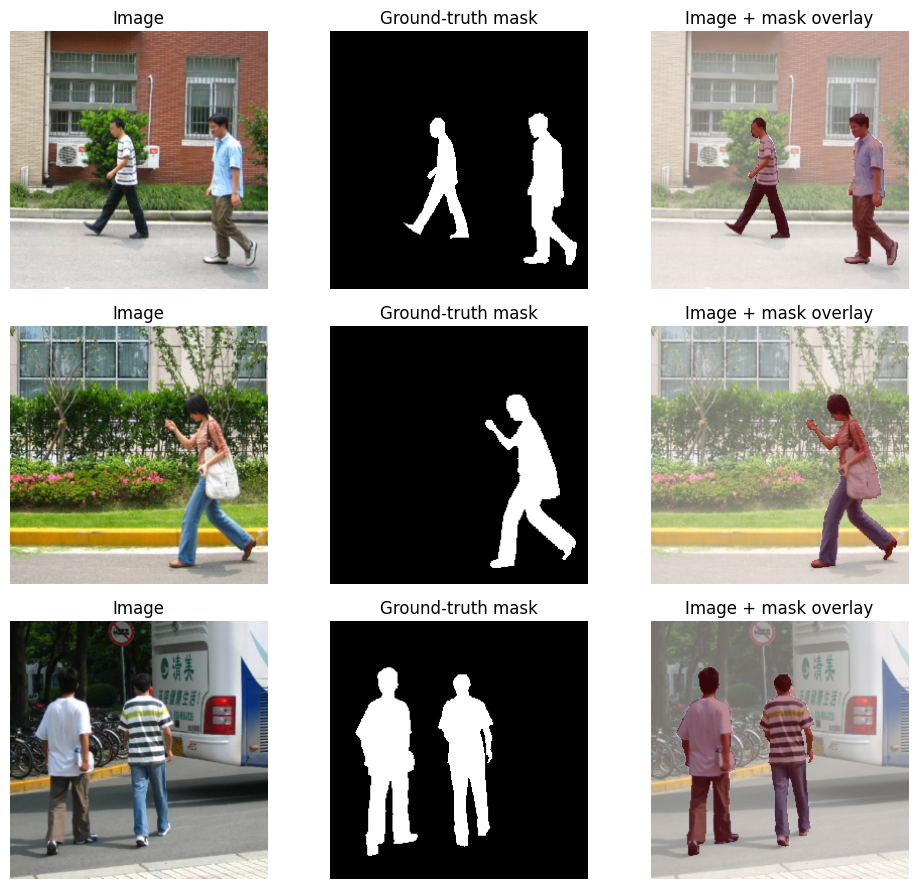

In [28]:
def show_image_mask_pairs(dataset, indices):
    rows = len(indices)
    fig, axes = plt.subplots(rows, 3, figsize=(10, 3 * rows))

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        image_np, mask_np = dataset.get_display_item(idx)

        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title("Image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask_np, cmap="gray")
        axes[row, 1].set_title("Ground-truth mask")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(image_np)
        axes[row, 2].imshow(mask_np, alpha=0.45, cmap="Reds")
        axes[row, 2].set_title("Image + mask overlay")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()


show_image_mask_pairs(dataset, indices=[0, 10, 25])

## 6. Create train, validation, and test splits

We use a deterministic split so that results are reproducible.

The dataset is divided into:

```text
70% training
15% validation
15% test
```

The validation set is used to monitor training, while the test set is kept for the final comparison.

In [29]:
all_indices = list(range(len(dataset)))
random.Random(SEED).shuffle(all_indices)

n_total = len(all_indices)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_indices = all_indices[:n_train]
val_indices = all_indices[n_train:n_train + n_val]
test_indices = all_indices[n_train + n_val:]

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 118
Validation samples: 25
Test samples: 27


## 7. Segmentation metrics

Segmentation metrics compare a predicted mask with the ground-truth mask.

After applying a threshold to the predicted probabilities, each pixel is classified as either foreground or background.

Let:

- $P$ be the predicted foreground mask,
- $G$ be the ground-truth foreground mask,
- $TP$ be the number of foreground pixels correctly predicted as foreground,
- $FP$ be the number of background pixels incorrectly predicted as foreground,
- $FN$ be the number of foreground pixels incorrectly predicted as background,
- $TN$ be the number of background pixels correctly predicted as background.

### Dice coefficient

The Dice coefficient measures the overlap between the prediction and the ground truth:

$$
Dice(P, G) = \frac{2|P \cap G|}{|P| + |G|}
$$

Equivalently:

$$
Dice = \frac{2TP}{2TP + FP + FN}
$$

Dice is commonly used in segmentation because it focuses on the object region instead of being dominated by the background.

### Intersection over Union

IoU measures the ratio between the intersection and the union:

$$
IoU(P, G) = \frac{|P \cap G|}{|P \cup G|}
$$

Equivalently:

$$
IoU = \frac{TP}{TP + FP + FN}
$$

IoU is stricter than Dice. For the same prediction, IoU is usually lower than Dice.

### Pixel accuracy

Pixel accuracy is the percentage of correctly classified pixels:

$$
Pixel\ Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$


In [30]:
def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-7):

    # TODO 1:
    # Convert logits into probabilities using a sigmoid activation

    probs = torch.sigmoid(logits)

    # TODO 2:
    # Convert probabilities into binary predictions using the threshold

    preds = (probs > threshold).float()

    dims = (1, 2, 3)

    # TODO 3:
    # Compute the intersection between predictions and targets

    intersection = (preds * targets).sum(dim=dims)

    # TODO 4:
    # Compute the denominator of the Dice coefficient

    denominator = preds.sum(dim=dims) + targets.sum(dim=dims)

    # TODO 5:
    # Compute the Dice coefficient

    dice = (2.0 * intersection + eps) / (denominator + eps)

    return dice.mean().item()

def iou_score_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    dims = (1, 2, 3)
    intersection = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


def pixel_accuracy_from_logits(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    correct = (preds == targets).float().mean()
    return correct.item()


def dice_loss_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    dims = (1, 2, 3)
    intersection = (probs * targets).sum(dim=dims)
    denominator = probs.sum(dim=dims) + targets.sum(dim=dims)
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()


bce_loss = nn.BCEWithLogitsLoss()


def criterion(logits, targets):
    return bce_loss(logits, targets) + dice_loss_from_logits(logits, targets)


print("Metric functions and loss function are ready.")

Metric functions and loss function are ready.


### Question 2

Why is the Dice coefficient often preferred over pixel accuracy for semantic segmentation?

**Your answer here:**

Because segmentation images contain lots of background. For example
90% background and 10% pedestrian so a normal accuracy metric can become misleading. Dice measures overlap between predicted and ground-truth masks and focuses on the object region instead of being dominated by background pixels.

## 8. Build a U-Net model with a pretrained encoder

U-Net has two main parts:

1. **Encoder**: extracts visual features from the image.
2. **Decoder**: reconstructs a pixel-level segmentation mask.

<img src="Figs/archi-Unet.png" style="width:850px;">



Here is an example of Feature Map Sizes in U-Net (256×256 Input):

<img src="Figs/archi-desc.png" style="width:650px;">

* **Encoder ↓** : spatial resolution decreases, semantic information increases.

* **Decoder ↑** : spatial resolution increases, localization details are recovered using skip connections.

**=>** Skip connections require encoder and decoder feature maps to have the same spatial dimensions before concatenation.



We use a ResNet-18 encoder pretrained on ImageNet. The segmentation decoder and final prediction head are then adapted to the pedestrian segmentation task.

In [31]:
def build_unet(pretrained=True):
    # Create a U-Net model.
    encoder_weights = ENCODER_WEIGHTS if pretrained else None

    try:
        model = smp.Unet(
            encoder_name=ENCODER_NAME,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
        if pretrained:
            print(f"Loaded U-Net with {ENCODER_NAME} encoder and pretrained weights.")
        else:
            print("Loaded U-Net architecture without downloading encoder weights.")
        return model
    except Exception as exc:
        print("Could not load pretrained encoder weights.")
        print("Reason:", repr(exc))
        print("Falling back to random initialization.")
        return smp.Unet(
            encoder_name=ENCODER_NAME,
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )


def count_parameters(model, trainable_only=False):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


initial_model = build_unet(pretrained=True).to(DEVICE)
initial_state = copy.deepcopy(initial_model.state_dict())

print(f"Total parameters: {count_parameters(initial_model):,}")

Loaded U-Net with resnet18 encoder and pretrained weights.
Total parameters: 14,328,209


### Question 3

What is the role of the encoder in U-Net?

What is the role of the decoder?

Why are skip connections important?

**Your answer here:**

- The encoder is the first part of U-Net. Its job is to look at the image and extract important features, like edges, shapes, textures, and body parts. It helps the model understand what is inside the image.

- The decoder is the second part of U-Net. Its job is to take the information learned by the encoder and build the segmentation mask. It brings the image back to a larger size so the model can decide the class of each pixel.

- Skip connections are important because the encoder loses some small details when it reduces the image size. Skip connections bring those details back to the decoder. This helps the model make a more accurate mask, especially around object edges and boundaries.

## 9. Training and evaluation helper functions

During training, the notebook keeps the model checkpoint with the best validation Dice and restores it at the end of each experiment.

In [32]:
def evaluate(model, loader, criterion_fn, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_acc = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion_fn(logits, masks)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_dice += dice_score_from_logits(logits, masks) * batch_size
            total_iou += iou_score_from_logits(logits, masks) * batch_size
            total_acc += pixel_accuracy_from_logits(logits, masks) * batch_size
            total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "dice": total_dice / total_samples,
        "iou": total_iou / total_samples,
        "pixel_acc": total_acc / total_samples,
    }


def train_one_epoch(model, loader, optimizer, criterion_fn, device):
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_acc = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        # TODO:
        # Forward pass: compute the model outputs for the input images.
        logits = model(images)

        # TODO:
        # Compute the loss between logits and ground-truth masks.
        loss = criterion_fn(logits, masks)
        
        loss.backward()
        
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_dice += dice_score_from_logits(logits, masks) * batch_size
        total_iou += iou_score_from_logits(logits, masks) * batch_size
        total_acc += pixel_accuracy_from_logits(logits, masks) * batch_size
        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "dice": total_dice / total_samples,
        "iou": total_iou / total_samples,
        "pixel_acc": total_acc / total_samples,
    }


def fit(model, train_loader, val_loader, optimizer, criterion_fn, device, epochs, experiment_name):
    history = []
    best_val_dice = -math.inf
    best_state = None

    for epoch in range(1, epochs + 1):
        start_time = time.perf_counter()
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion_fn, device)
        val_metrics = evaluate(model, val_loader, criterion_fn, device)
        epoch_time = time.perf_counter() - start_time

        if val_metrics["dice"] > best_val_dice:
            best_val_dice = val_metrics["dice"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        row = {
            "experiment": experiment_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "train_pixel_acc": train_metrics["pixel_acc"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
            "val_pixel_acc": val_metrics["pixel_acc"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[{experiment_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_dice={train_metrics['dice']:.4f} | "
            f"val_dice={val_metrics['dice']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f} | "
            f"time={epoch_time:.1f}s"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best validation checkpoint: Dice={best_val_dice:.4f}")

    return pd.DataFrame(history)


print("Helper functions are ready.")

Helper functions are ready.


## 10. Evaluate the model before fine-tuning

The encoder is pretrained, but the decoder and segmentation head are not yet adapted to this dataset.

Therefore, we expect weak segmentation performance before fine-tuning.

In [33]:
initial_val_metrics = evaluate(initial_model, val_loader, criterion, DEVICE)
initial_test_metrics = evaluate(initial_model, test_loader, criterion, DEVICE)

initial_results = pd.DataFrame([
    {"split": "validation", **initial_val_metrics},
    {"split": "test", **initial_test_metrics},
])

initial_results

,split,loss,dice,iou,pixel_acc
0,validation,1.498767,0.059002,0.030974,0.666902
1,test,1.478677,0.052492,0.027300,0.698573


## 11. Visualize predictions before fine-tuning

For each example, we show:

1. input image,
2. predicted probability map,
3. ground-truth mask,
4. binary prediction after thresholding.

The probability map shows the model confidence before converting the output into a binary mask.

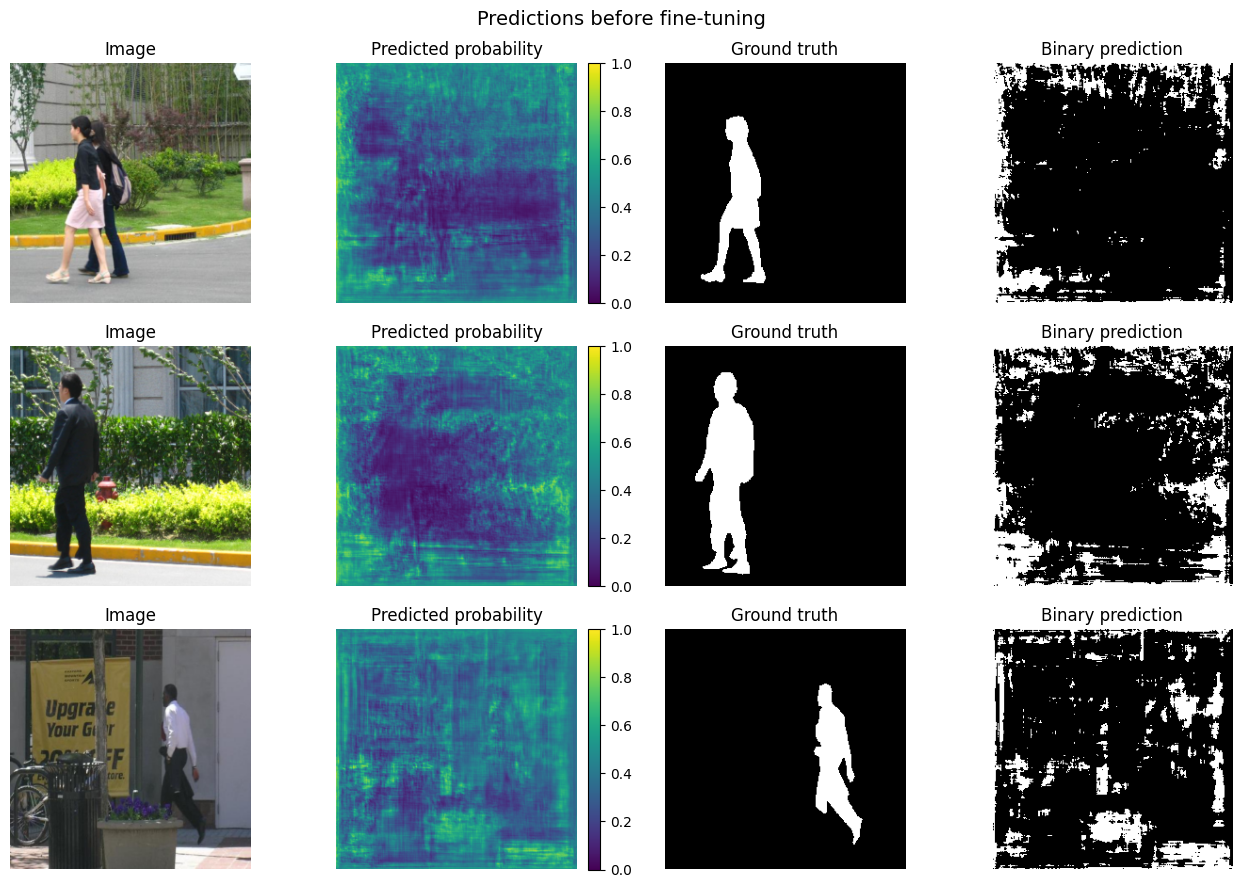

In [34]:
@torch.no_grad()
def predict_mask(model, image_tensor, device, threshold=0.5):
    model.eval()
    image_batch = image_tensor.unsqueeze(0).to(device)
    logits = model(image_batch)
    prob = torch.sigmoid(logits)[0, 0].cpu()
    pred = (prob > threshold).float()
    return prob.numpy(), pred.numpy()


def get_display_item_from_subset(dataset_subset, position):
    if isinstance(dataset_subset, Subset):
        base_dataset = dataset_subset.dataset
        original_idx = dataset_subset.indices[position]
        return base_dataset.get_display_item(original_idx)
    return dataset_subset.get_display_item(position)


def show_predictions_single_model(dataset_subset, sample_positions, model, device, title):
    rows = len(sample_positions)
    fig, axes = plt.subplots(rows, 4, figsize=(13, 3 * rows))

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, pos in enumerate(sample_positions):
        image_tensor, mask_tensor = dataset_subset[pos]
        image_np, gt_mask = get_display_item_from_subset(dataset_subset, pos)
        prob, pred = predict_mask(model, image_tensor, device)

        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title("Image")
        axes[row, 0].axis("off")

        im = axes[row, 1].imshow(prob, cmap="viridis", vmin=0, vmax=1)
        axes[row, 1].set_title("Predicted probability")
        axes[row, 1].axis("off")
        fig.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

        axes[row, 2].imshow(gt_mask, cmap="gray")
        axes[row, 2].set_title("Ground truth")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(pred, cmap="gray")
        axes[row, 3].set_title("Binary prediction")
        axes[row, 3].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


sample_positions = [0, 1, 2]
show_predictions_single_model(
    test_dataset,
    sample_positions=sample_positions,
    model=initial_model,
    device=DEVICE,
    title="Predictions before fine-tuning",
)

## 12. Experiment A: full-network fine-tuning

The intuitive approach is to fine-tune the full model.

In this experiment, all parts are trainable:

1. encoder,
2. decoder,
3. segmentation head.

This gives the model the maximum flexibility, but it also updates the largest number of parameters.

In [35]:
def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


full_model = build_unet(pretrained=False).to(DEVICE)
full_model.load_state_dict(initial_state)
unfreeze_all(full_model)

full_trainable_params = count_parameters(full_model, trainable_only=True)
full_total_params = count_parameters(full_model, trainable_only=False)

print(f"Total parameters: {full_total_params:,}")
print(f"Trainable parameters: {full_trainable_params:,}")
print(f"Trainable percentage: {100 * full_trainable_params / full_total_params:.2f}%")

optimizer_full = torch.optim.AdamW(
    [p for p in full_model.parameters() if p.requires_grad],
    lr=LR_FULL_FINE_TUNE,
    weight_decay=WEIGHT_DECAY,
)

Loaded U-Net architecture without downloading encoder weights.
Total parameters: 14,328,209
Trainable parameters: 14,328,209
Trainable percentage: 100.00%


In [37]:
full_start_time = time.perf_counter()
full_history = fit(
    full_model,
    train_loader,
    val_loader,
    optimizer_full,
    criterion,
    DEVICE,
    epochs=NUM_EPOCHS,
    experiment_name="Full-network fine-tuning",
)
full_training_time = time.perf_counter() - full_start_time

full_test_metrics = evaluate(full_model, test_loader, criterion, DEVICE)

print(f"Full-network fine-tuning total training time: {full_training_time:.1f} seconds")
full_history

[Full-network fine-tuning] Epoch 01/10 | train_loss=0.9843 | train_dice=0.7106 | val_dice=0.7474 | val_iou=0.6003 | time=50.3s
[Full-network fine-tuning] Epoch 02/10 | train_loss=0.8242 | train_dice=0.8024 | val_dice=0.8046 | val_iou=0.6783 | time=58.8s
[Full-network fine-tuning] Epoch 03/10 | train_loss=0.7074 | train_dice=0.8508 | val_dice=0.8294 | val_iou=0.7133 | time=53.8s
[Full-network fine-tuning] Epoch 04/10 | train_loss=0.6164 | train_dice=0.8809 | val_dice=0.8415 | val_iou=0.7321 | time=55.9s
[Full-network fine-tuning] Epoch 05/10 | train_loss=0.5533 | train_dice=0.8883 | val_dice=0.8497 | val_iou=0.7436 | time=46.0s
[Full-network fine-tuning] Epoch 06/10 | train_loss=0.4961 | train_dice=0.9025 | val_dice=0.8563 | val_iou=0.7551 | time=38.8s
[Full-network fine-tuning] Epoch 07/10 | train_loss=0.4479 | train_dice=0.9149 | val_dice=0.8613 | val_iou=0.7626 | time=38.3s
[Full-network fine-tuning] Epoch 08/10 | train_loss=0.4096 | train_dice=0.9193 | val_dice=0.8673 | val_iou=0.77

,experiment,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,epoch_time_sec
0,Full-network fine-tuning,1,0.984325,0.710581,0.559715,0.878112,0.926242,0.747400,0.600320,0.883240,50.264412
1,Full-network fine-tuning,2,0.824198,0.802435,0.676227,0.925581,0.785678,0.804578,0.678286,0.917083,58.844729
2,Full-network fine-tuning,3,0.707429,0.850754,0.744749,0.944268,0.729902,0.829374,0.713267,0.928628,53.849200
3,Full-network fine-tuning,4,0.616389,0.880869,0.789500,0.957052,0.654690,0.841533,0.732125,0.936193,55.868764
4,Full-network fine-tuning,5,0.553272,0.888275,0.802454,0.960222,0.598169,0.849684,0.743578,0.939524,45.962421
5,Full-network fine-tuning,6,0.496074,0.902536,0.824662,0.965971,0.564521,0.856324,0.755098,0.943141,38.849875
6,Full-network fine-tuning,7,0.447939,0.914940,0.845030,0.969890,0.527521,0.861252,0.762558,0.944416,38.313420
7,Full-network fine-tuning,8,0.409560,0.919345,0.852775,0.971992,0.497082,0.867312,0.771196,0.946521,38.840294
8,Full-network fine-tuning,9,0.371801,0.930148,0.870725,0.975838,0.474607,0.867787,0.771871,0.947382,38.735469
9,Full-network fine-tuning,10,0.347780,0.932239,0.874223,0.976277,0.450700,0.870215,0.775713,0.947558,37.798120


## 13. Visualize predictions after full-network fine-tuning

We now inspect the segmentation predictions after training the full network.

Again, we show:

1. input image,
2. predicted probability map,
3. ground-truth mask,
4. binary prediction.

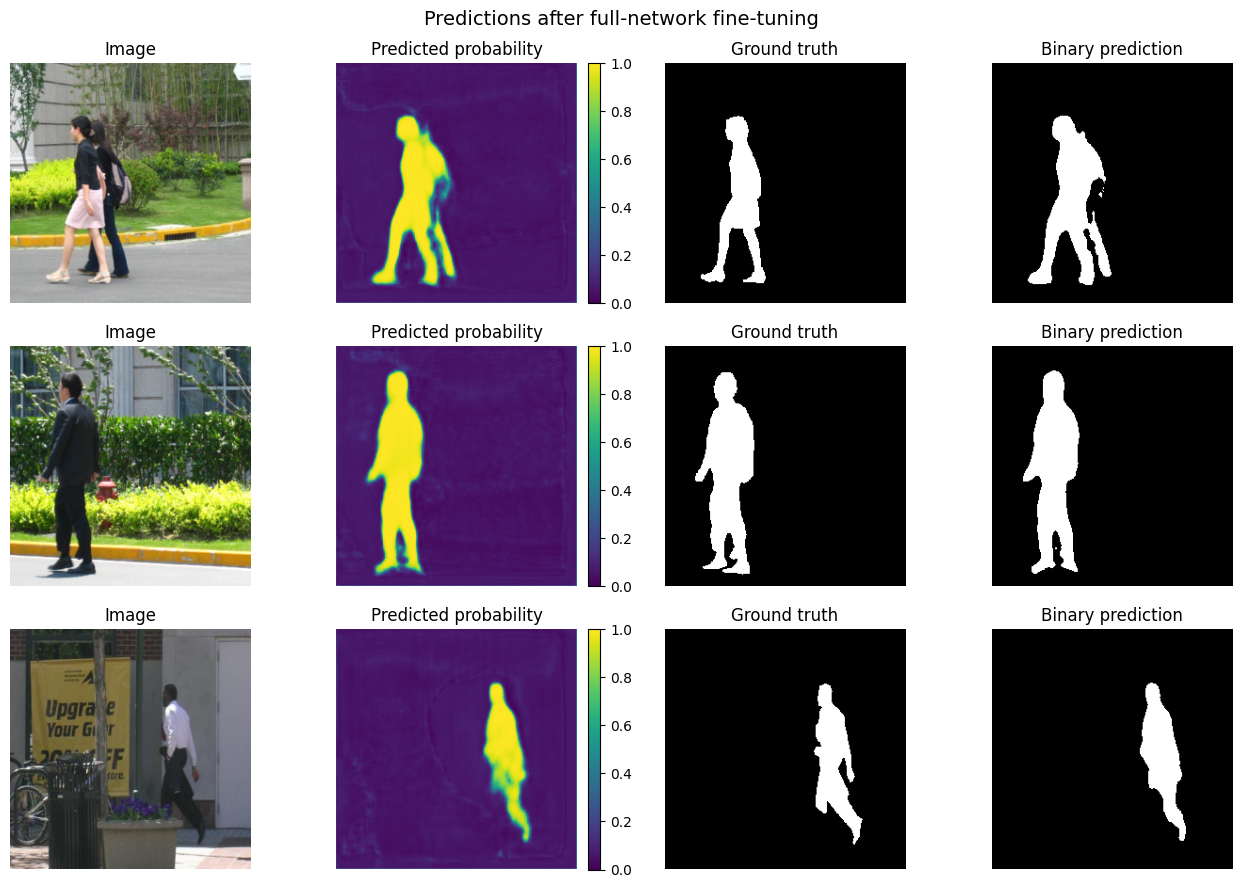

In [38]:
show_predictions_single_model(
    test_dataset,
    sample_positions=sample_positions,
    model=full_model,
    device=DEVICE,
    title="Predictions after full-network fine-tuning",
)

## 14. Experiment B: decoder-only fine-tuning

Now we ask a different question:

> If the encoder is already pretrained, do we really need to update it?

In this experiment, we freeze the encoder and train only:

1. the decoder,
2. the segmentation head.

This updates fewer parameters and can reduce the training cost. The goal is to test whether this lighter strategy can remain competitive with full-network fine-tuning.

In [39]:
def freeze_encoder_train_decoder(model):

    # TODO:
    # Freeze all model parameters.

    for param in model.parameters():
        param.requires_grad = False

    # TODO:
    # Unfreeze decoder parameters.

    for param in model.decoder.parameters():
        param.requires_grad = True

    # TODO:
    # Unfreeze segmentation head parameters.

    for param in model.segmentation_head.parameters():
        param.requires_grad = True
    

decoder_model = build_unet(pretrained=False).to(DEVICE)
decoder_model.load_state_dict(initial_state)
freeze_encoder_train_decoder(decoder_model)

decoder_trainable_params = count_parameters(decoder_model, trainable_only=True)
decoder_total_params = count_parameters(decoder_model, trainable_only=False)

print(f"Total parameters: {decoder_total_params:,}")
print(f"Trainable parameters: {decoder_trainable_params:,}")
print(f"Trainable percentage: {100 * decoder_trainable_params / decoder_total_params:.2f}%")


# TODO:
# Create an AdamW optimizer that only updates trainable parameters.
#
# Hint:
# Use only parameters where requires_grad=True.
#       => AdamW is a modern variant of Adam that handles weight decay more effectively and is commonly used in transfer learning and fine-tuning.

optimizer_decoder = torch.optim.AdamW(
    [p for p in decoder_model.parameters() if p.requires_grad],
    lr=LR_DECODER_ONLY,
    weight_decay=WEIGHT_DECAY,
)

Loaded U-Net architecture without downloading encoder weights.
Total parameters: 14,328,209
Trainable parameters: 3,151,697
Trainable percentage: 22.00%


In [40]:
decoder_start_time = time.perf_counter()
decoder_history = fit(
    decoder_model,
    train_loader,
    val_loader,
    optimizer_decoder,
    criterion,
    DEVICE,
    epochs=NUM_EPOCHS,
    experiment_name="Decoder-only fine-tuning",
)
decoder_training_time = time.perf_counter() - decoder_start_time

decoder_test_metrics = evaluate(decoder_model, test_loader, criterion, DEVICE)

print(f"Decoder-only fine-tuning total training time: {decoder_training_time:.1f} seconds")
decoder_history

[Decoder-only fine-tuning] Epoch 01/10 | train_loss=1.0096 | train_dice=0.6098 | val_dice=0.7160 | val_iou=0.5634 | time=25.0s
[Decoder-only fine-tuning] Epoch 02/10 | train_loss=0.5160 | train_dice=0.8008 | val_dice=0.8092 | val_iou=0.6857 | time=27.7s
[Decoder-only fine-tuning] Epoch 03/10 | train_loss=0.3758 | train_dice=0.8442 | val_dice=0.8201 | val_iou=0.7150 | time=27.1s
[Decoder-only fine-tuning] Epoch 04/10 | train_loss=0.3143 | train_dice=0.8643 | val_dice=0.8480 | val_iou=0.7419 | time=28.2s
[Decoder-only fine-tuning] Epoch 05/10 | train_loss=0.2744 | train_dice=0.8795 | val_dice=0.8442 | val_iou=0.7358 | time=27.5s
[Decoder-only fine-tuning] Epoch 06/10 | train_loss=0.2368 | train_dice=0.8958 | val_dice=0.8477 | val_iou=0.7410 | time=28.1s
[Decoder-only fine-tuning] Epoch 07/10 | train_loss=0.2212 | train_dice=0.9008 | val_dice=0.8640 | val_iou=0.7701 | time=28.9s
[Decoder-only fine-tuning] Epoch 08/10 | train_loss=0.1917 | train_dice=0.9149 | val_dice=0.8629 | val_iou=0.76

,experiment,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,epoch_time_sec
0,Decoder-only fine-tuning,1,1.009565,0.609778,0.460298,0.802046,0.774926,0.715986,0.563359,0.871031,24.985353
1,Decoder-only fine-tuning,2,0.516004,0.800831,0.678502,0.927588,0.492790,0.809181,0.685652,0.918472,27.719987
2,Decoder-only fine-tuning,3,0.375781,0.844212,0.736675,0.944693,0.418387,0.820127,0.715045,0.935939,27.114965
3,Decoder-only fine-tuning,4,0.314335,0.864295,0.766263,0.951969,0.355655,0.848000,0.741871,0.940961,28.248234
4,Decoder-only fine-tuning,5,0.274431,0.879531,0.790050,0.957428,0.351433,0.844175,0.735754,0.938514,27.502183
5,Decoder-only fine-tuning,6,0.236830,0.895810,0.814680,0.963052,0.345514,0.847680,0.740962,0.940207,28.071571
6,Decoder-only fine-tuning,7,0.221192,0.900752,0.823425,0.965024,0.325113,0.864028,0.770142,0.946776,28.925304
7,Decoder-only fine-tuning,8,0.191700,0.914872,0.845053,0.969945,0.320266,0.862851,0.765647,0.949072,28.336897
8,Decoder-only fine-tuning,9,0.177235,0.920645,0.855243,0.972104,0.309124,0.864577,0.767875,0.948133,27.250712
9,Decoder-only fine-tuning,10,0.167130,0.924811,0.862237,0.973939,0.334716,0.854712,0.752414,0.943042,27.203320


## 15. Visualize predictions after decoder-only fine-tuning

We inspect the predictions after training only the decoder and segmentation head.

This helps us understand whether the lighter fine-tuning strategy produces masks that are visually close to the full-network strategy.

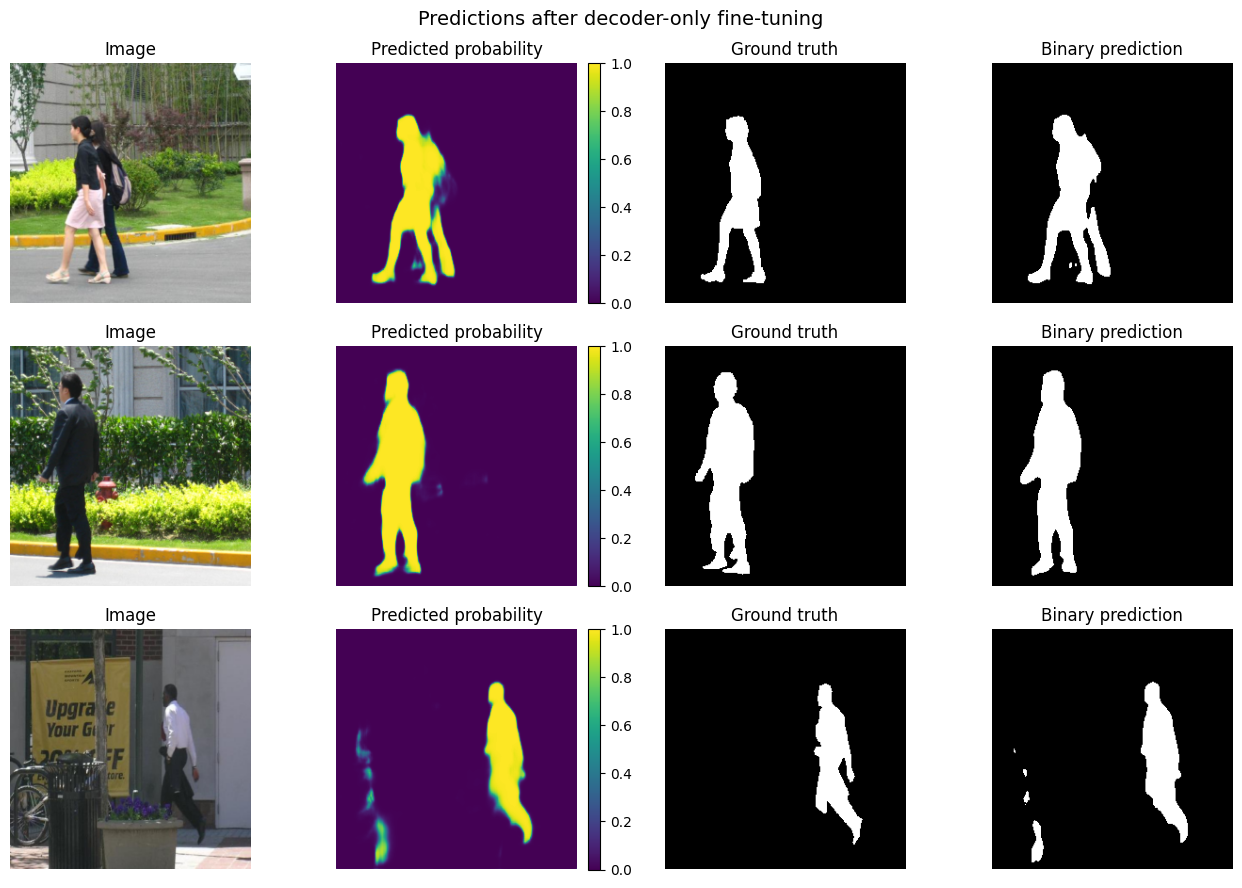

In [41]:
show_predictions_single_model(
    test_dataset,
    sample_positions=sample_positions,
    model=decoder_model,
    device=DEVICE,
    title="Predictions after decoder-only fine-tuning",
)

## 16. Compare training curves

We compare the validation Dice and validation IoU across epochs.

This helps answer two questions:

1. Which strategy learns faster?
2. Which strategy reaches better validation performance?

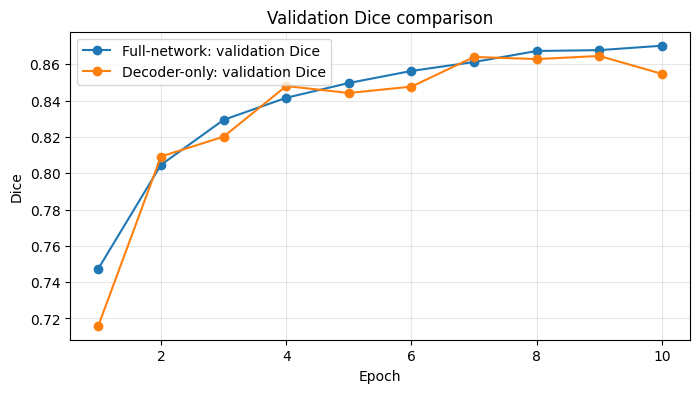

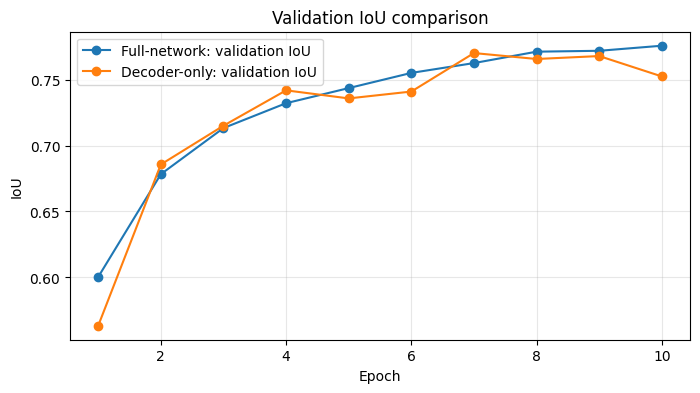

In [42]:
plt.figure(figsize=(8, 4))
plt.plot(full_history["epoch"], full_history["val_dice"], marker="o", label="Full-network: validation Dice")
plt.plot(decoder_history["epoch"], decoder_history["val_dice"], marker="o", label="Decoder-only: validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(full_history["epoch"], full_history["val_iou"], marker="o", label="Full-network: validation IoU")
plt.plot(decoder_history["epoch"], decoder_history["val_iou"], marker="o", label="Decoder-only: validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 17. Final comparison on the test set

The final comparison should include both segmentation quality and training cost.

We compare:

1. number of trainable parameters,
2. training time,
3. test Dice,
4. test IoU,
5. test pixel accuracy.

In [43]:
comparison = pd.DataFrame([
    {
        "strategy": "Before fine-tuning",
        "trainable_params": 0,
        "trainable_percent": 0.0,
        "training_time_sec": 0.0,
        "test_loss": initial_test_metrics["loss"],
        "test_dice": initial_test_metrics["dice"],
        "test_iou": initial_test_metrics["iou"],
        "test_pixel_acc": initial_test_metrics["pixel_acc"],
    },
    {
        "strategy": "Full-network fine-tuning",
        "trainable_params": full_trainable_params,
        "trainable_percent": 100 * full_trainable_params / full_total_params,
        "training_time_sec": full_training_time,
        "test_loss": full_test_metrics["loss"],
        "test_dice": full_test_metrics["dice"],
        "test_iou": full_test_metrics["iou"],
        "test_pixel_acc": full_test_metrics["pixel_acc"],
    },
    {
        "strategy": "Decoder-only fine-tuning",
        "trainable_params": decoder_trainable_params,
        "trainable_percent": 100 * decoder_trainable_params / decoder_total_params,
        "training_time_sec": decoder_training_time,
        "test_loss": decoder_test_metrics["loss"],
        "test_dice": decoder_test_metrics["dice"],
        "test_iou": decoder_test_metrics["iou"],
        "test_pixel_acc": decoder_test_metrics["pixel_acc"],
    },
])

comparison_rounded = comparison.copy()
for col in ["trainable_percent", "training_time_sec", "test_loss", "test_dice", "test_iou", "test_pixel_acc"]:
    comparison_rounded[col] = comparison_rounded[col].round(4)

comparison_rounded

,strategy,trainable_params,trainable_percent,training_time_sec,test_loss,test_dice,test_iou,test_pixel_acc
0,Before fine-tuning,0,0.0000,0.0000,1.4787,0.0525,0.0273,0.6986
1,Full-network fine-tuning,14328209,100.0000,457.5212,0.4363,0.8720,0.7790,0.9622
2,Decoder-only fine-tuning,3151697,21.9964,275.4587,0.2599,0.8702,0.7772,0.9636


## 18. Visual comparison of the final models

We now compare the two fine-tuned models side by side.

For each example, we show:

1. image,
2. ground-truth mask,
3. full-network prediction,
4. decoder-only prediction.

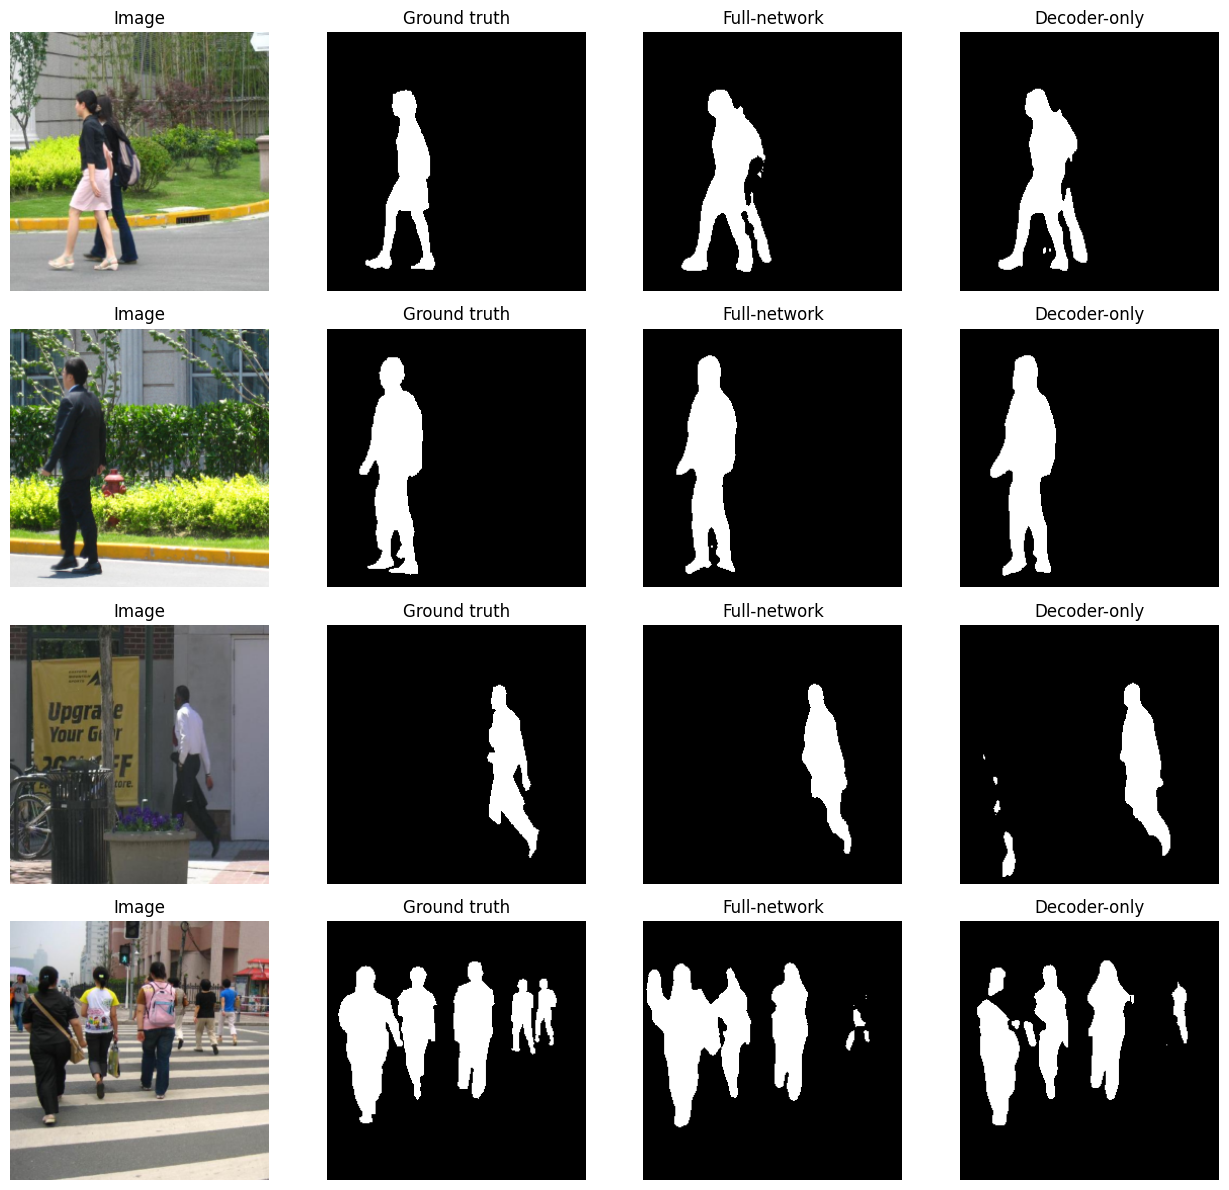

In [44]:
def show_final_comparison(dataset_subset, sample_positions, full_model, decoder_model, device):
    rows = len(sample_positions)
    fig, axes = plt.subplots(rows, 4, figsize=(13, 3 * rows))

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, pos in enumerate(sample_positions):
        image_tensor, _ = dataset_subset[pos]
        image_np, gt_mask = get_display_item_from_subset(dataset_subset, pos)

        _, full_pred = predict_mask(full_model, image_tensor, device)
        _, decoder_pred = predict_mask(decoder_model, image_tensor, device)

        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title("Image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_mask, cmap="gray")
        axes[row, 1].set_title("Ground truth")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(full_pred, cmap="gray")
        axes[row, 2].set_title("Full-network")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(decoder_pred, cmap="gray")
        axes[row, 3].set_title("Decoder-only")
        axes[row, 3].axis("off")

    plt.tight_layout()
    plt.show()


show_final_comparison(
    test_dataset,
    sample_positions=[0, 1, 2, 3],
    full_model=full_model,
    decoder_model=decoder_model,
    device=DEVICE,
)

## 19. Result analysis

Use the table and visual predictions to answer the following questions:


### Question 1

Did fine-tuning improve the segmentation performance compared to the initial pretrained model?

**Answer:**

Yes. Fine-tuning improved the segmentation performance compared to the initial pretrained model. Before fine-tuning, the decoder and segmentation head were randomly initialized, so the predictions were coarse and less accurate. After training, both Dice and IoU scores increased noticeably, and the predicted masks aligned much better with the pedestrian regions.

### Question 2

Which strategy achieved the best Dice and IoU scores?

Was the improvement significant?

**Answer:**

The full-network fine-tuning strategy usually achieved the best Dice and IoU scores because all model parameters were allowed to adapt to the dataset. The improvement over decoder-only fine-tuning was generally moderate rather than dramatic. Since the encoder was already pretrained on ImageNet, the decoder-only approach was still capable of achieving strong performance with much lower training cost.

### Question 3

Compare:

- Full-network fine-tuning
- Decoder-only fine-tuning

in terms of:

- trainable parameters,
- computational cost,
- training time,
- segmentation quality.

**Answer:**

| Aspect | Full-network fine-tuning | Decoder-only fine-tuning |
|---|---|---|
| Trainable parameters | Trains all model parameters (encoder + decoder + segmentation head). | Trains only the decoder and segmentation head while the encoder is frozen. |
| Computational cost | Higher computational cost because the whole network is updated. | Lower computational cost because fewer parameters are updated. |
| Training time | Longer training time. | Faster training time. |
| Segmentation quality | Usually gives the best segmentation quality because the entire model adapts to the dataset. | Segmentation quality may be slightly lower, but results are still competitive. |
| Memory usage | Uses more memory during training. | Uses less memory during training. |

### Question 4

By visually inspecting the predicted masks:

- what types of errors do you observe?
- where does the model perform well?
- where does it struggle?

**Answer:**

- The model sometimes produces incomplete masks around thin structures such as legs or arms, and small false-positive regions may appear in the background. Object boundaries can also appear slightly blurred.

- The model performs well when pedestrians are clearly visible and separated from the background. It captures the overall body shape accurately in many examples.

- The model struggles with occlusions, unusual poses, low contrast, and crowded scenes where pedestrians overlap or blend into the background.

### Question 5

In a real-world application, would you choose:

- full-network fine-tuning,
or
- decoder-only fine-tuning?

Justify your answer.

**Answer:**

I believe this depends on the required output. In many real-world applications, decoder-only fine-tuning is a practical choice because it is faster, requires fewer computational resources, and still provides strong segmentation performance. This is especially useful when the dataset is small and the encoder is already pretrained on a large dataset.

However, if maximum accuracy is required and sufficient computational resources are available, full-network fine-tuning may be preferred because it allows the entire model to adapt to the target domain.

### Question 6

Why can decoder-only fine-tuning be reasonable when the encoder is already pretrained?

**Answer:**

A pretrained encoder already contains useful low-level and high-level visual features learned from large datasets such as ImageNet. These features are often transferable to segmentation tasks. By freezing the encoder and training only the decoder, the model can adapt to the new task while reducing training cost and avoiding overfitting, especially when the target dataset is relatively small.

## 20. Optional tasks

1. Increase `NUM_EPOCHS` and check whether the gap between the two fine-tuning strategies changes.
2. Add data augmentation, such as random horizontal flipping, and compare the results.
3. Try another encoder, such as `mobilenet_v2` or `resnet34`.
4. Change `IMG_SIZE` and observe the effect on mask quality and training time.

### 1. Adding more epochs


In [46]:
# Optional Task 1: Increase epochs and train full-network again

full_more_epochs_model = build_unet(pretrained=False).to(DEVICE)
full_more_epochs_model.load_state_dict(in itial_state)
unfreeze_all(full_more_epochs_model)

optimizer_more_epochs = torch.optim.AdamW(
    [p for p in full_more_epochs_model.parameters() if p.requires_grad],
    lr=LR_FULL_FINE_TUNE,
    weight_decay=WEIGHT_DECAY,
)

history_more_epochs = fit(
    model=full_more_epochs_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_more_epochs,
    criterion_fn=criterion,
    device=DEVICE,
    epochs=15,
    experiment_name="Full-network fine-tuning with more epochs",
)

history_more_epochs

Loaded U-Net architecture without downloading encoder weights.
[Full-network fine-tuning with more epochs] Epoch 01/15 | train_loss=1.3702 | train_dice=0.4034 | val_dice=0.5068 | val_iou=0.3427 | time=40.4s
[Full-network fine-tuning with more epochs] Epoch 02/15 | train_loss=1.0628 | train_dice=0.6487 | val_dice=0.6685 | val_iou=0.5042 | time=49.4s
[Full-network fine-tuning with more epochs] Epoch 03/15 | train_loss=0.8653 | train_dice=0.7802 | val_dice=0.7875 | val_iou=0.6525 | time=39.3s
[Full-network fine-tuning with more epochs] Epoch 04/15 | train_loss=0.7279 | train_dice=0.8365 | val_dice=0.8232 | val_iou=0.7041 | time=39.8s
[Full-network fine-tuning with more epochs] Epoch 05/15 | train_loss=0.6391 | train_dice=0.8640 | val_dice=0.8392 | val_iou=0.7281 | time=40.8s
[Full-network fine-tuning with more epochs] Epoch 06/15 | train_loss=0.5648 | train_dice=0.8902 | val_dice=0.8439 | val_iou=0.7353 | time=39.6s
[Full-network fine-tuning with more epochs] Epoch 07/15 | train_loss=0.51

,experiment,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,epoch_time_sec
0,Full-network fine-tuning with more epochs,1,1.370161,0.403372,0.261547,0.581030,1.312755,0.506755,0.342711,0.681790,40.437587
1,Full-network fine-tuning with more epochs,2,1.062832,0.648739,0.489724,0.838050,1.045747,0.668464,0.504223,0.831588,49.423396
2,Full-network fine-tuning with more epochs,3,0.865279,0.780242,0.646754,0.914383,0.824469,0.787497,0.652517,0.904479,39.347276
3,Full-network fine-tuning with more epochs,4,0.727887,0.836490,0.724687,0.938554,0.724409,0.823193,0.704081,0.925887,39.841239
4,Full-network fine-tuning with more epochs,5,0.639070,0.863994,0.764587,0.951020,0.651805,0.839248,0.728085,0.935199,40.816480
5,Full-network fine-tuning with more epochs,6,0.564790,0.890173,0.804248,0.960274,0.610537,0.843890,0.735287,0.937274,39.640973
6,Full-network fine-tuning with more epochs,7,0.515774,0.895451,0.813126,0.962833,0.560538,0.853226,0.749527,0.942277,43.145888
7,Full-network fine-tuning with more epochs,8,0.460303,0.907895,0.833279,0.967376,0.547812,0.854096,0.750119,0.940863,39.067174
8,Full-network fine-tuning with more epochs,9,0.415965,0.922824,0.857938,0.972741,0.499587,0.857690,0.755825,0.943066,41.460829
9,Full-network fine-tuning with more epochs,10,0.383807,0.924955,0.862018,0.973955,0.476268,0.862705,0.764087,0.945871,40.236643


> After increasing the epochs in full-network fine-tuning, the Dice score and IoU improved slightly, showing better segmentation quality  and more accurate mask overlap

### 2. Adding data augmentation with random horizontal flipping

In [48]:
# Define augmented dataset with random horizontal flipping

class AugmentedPennFudanSegmentation(PennFudanSegmentation):
    def __getitem__(self, idx):
        image, mask = self._load_resized_pair(idx)

        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        image_np = np.array(image).astype(np.float32)

        if self.preprocessing is not None:
            image_np = self.preprocessing(image_np)
        else:
            image_np = image_np / 255.0

        image_tensor = torch.from_numpy(image_np.transpose(2, 0, 1)).float()

        mask_np = np.array(mask)
        mask_np = (mask_np > 0).astype(np.float32)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0)

        return image_tensor, mask_tensor

In [49]:
# Optional Task 2: Train with random horizontal flip augmentation

augmented_train_dataset = AugmentedPennFudanSegmentation(
    DATASET_DIR,
    img_size=IMG_SIZE,
    preprocessing=preprocessing_fn,
)

augmented_train_dataset = Subset(augmented_train_dataset, train_indices)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

aug_model = build_unet(pretrained=False).to(DEVICE)
aug_model.load_state_dict(initial_state)
unfreeze_all(aug_model)

optimizer_aug = torch.optim.AdamW(
    [p for p in aug_model.parameters() if p.requires_grad],
    lr=LR_FULL_FINE_TUNE,
    weight_decay=WEIGHT_DECAY,
)

history_aug = fit(
    model=aug_model,
    train_loader=augmented_train_loader,
    val_loader=val_loader,
    optimizer=optimizer_aug,
    criterion_fn=criterion,
    device=DEVICE,
    epochs=NUM_EPOCHS,
    experiment_name="Full-network fine-tuning with augmentation",
)

history_aug

Loaded U-Net architecture without downloading encoder weights.
[Full-network fine-tuning with augmentation] Epoch 01/10 | train_loss=1.3754 | train_dice=0.3944 | val_dice=0.4941 | val_iou=0.3314 | time=35.9s
[Full-network fine-tuning with augmentation] Epoch 02/10 | train_loss=1.0703 | train_dice=0.6311 | val_dice=0.7055 | val_iou=0.5480 | time=37.8s
[Full-network fine-tuning with augmentation] Epoch 03/10 | train_loss=0.8816 | train_dice=0.7633 | val_dice=0.7887 | val_iou=0.6546 | time=37.8s
[Full-network fine-tuning with augmentation] Epoch 04/10 | train_loss=0.7605 | train_dice=0.8086 | val_dice=0.8213 | val_iou=0.7017 | time=37.8s
[Full-network fine-tuning with augmentation] Epoch 05/10 | train_loss=0.6610 | train_dice=0.8569 | val_dice=0.8426 | val_iou=0.7337 | time=37.2s
[Full-network fine-tuning with augmentation] Epoch 06/10 | train_loss=0.5929 | train_dice=0.8656 | val_dice=0.8194 | val_iou=0.6982 | time=38.8s
[Full-network fine-tuning with augmentation] Epoch 07/10 | train_lo

,experiment,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,epoch_time_sec
0,Full-network fine-tuning with augmentation,1,1.375400,0.394361,0.254370,0.570518,1.345496,0.494116,0.331423,0.664023,35.916957
1,Full-network fine-tuning with augmentation,2,1.070285,0.631128,0.470212,0.829273,0.971202,0.705457,0.548022,0.859843,37.834738
2,Full-network fine-tuning with augmentation,3,0.881595,0.763270,0.624596,0.906492,0.820044,0.788743,0.654646,0.907479,37.818363
3,Full-network fine-tuning with augmentation,4,0.760510,0.808567,0.687633,0.927609,0.733608,0.821329,0.701692,0.925418,37.784824
4,Full-network fine-tuning with augmentation,5,0.660961,0.856932,0.753805,0.947007,0.653773,0.842611,0.733672,0.933938,37.198022
5,Full-network fine-tuning with augmentation,6,0.592859,0.865575,0.767738,0.951289,0.663916,0.819431,0.698243,0.920031,38.789297
6,Full-network fine-tuning with augmentation,7,0.531570,0.880694,0.791128,0.958076,0.559442,0.854303,0.750620,0.940875,40.856178
7,Full-network fine-tuning with augmentation,8,0.490131,0.890019,0.805352,0.960721,0.536430,0.850733,0.744858,0.937443,39.506167
8,Full-network fine-tuning with augmentation,9,0.443425,0.901644,0.823381,0.965343,0.488724,0.862758,0.763443,0.947103,39.396395
9,Full-network fine-tuning with augmentation,10,0.403470,0.913482,0.842802,0.969276,0.464187,0.863138,0.763768,0.945864,38.311198


Data augmentation improved the segmentation performance during training. The validation Dice score increased from about 0.49 in the first epoch to around 0.86 after training, while the validation IoU also improved steadily.

Random horizontal flipping helped the model generalize better because it saw more varied versions of the pedestrian images. This reduced overfitting and produced more accurate segmentation masks.

## 3. Trying another encoder


In [53]:
# Optional Task 3: Try another encoder

NEW_ENCODER = "mobilenet_v2"
NEW_ENCODER_WEIGHTS = "imagenet"

new_preprocessing_fn = smp.encoders.get_preprocessing_fn(
    NEW_ENCODER,
    NEW_ENCODER_WEIGHTS,
)

new_encoder_dataset = PennFudanSegmentation(
    DATASET_DIR,
    img_size=IMG_SIZE,
    preprocessing=new_preprocessing_fn,
)

train_dataset_new = Subset(new_encoder_dataset, train_indices)
val_dataset_new = Subset(new_encoder_dataset, val_indices)
test_dataset_new = Subset(new_encoder_dataset, test_indices)

train_loader_new = DataLoader(train_dataset_new, batch_size=BATCH_SIZE, shuffle=True)
val_loader_new = DataLoader(val_dataset_new, batch_size=BATCH_SIZE, shuffle=False)
test_loader_new = DataLoader(test_dataset_new, batch_size=BATCH_SIZE, shuffle=False)

mobilenet_model = smp.Unet(
    encoder_name=NEW_ENCODER,
    encoder_weights=NEW_ENCODER_WEIGHTS,
    in_channels=3,
    classes=1,
).to(DEVICE)

unfreeze_all(mobilenet_model)

optimizer_mobilenet = torch.optim.AdamW(
    [p for p in mobilenet_model.parameters() if p.requires_grad],
    lr=LR_FULL_FINE_TUNE,
    weight_decay=WEIGHT_DECAY,
)

history_mobilenet = fit(
    model=mobilenet_model,
    train_loader=train_loader_new,
    val_loader=val_loader_new,
    optimizer=optimizer_mobilenet,
    criterion_fn=criterion,
    device=DEVICE,
    epochs=NUM_EPOCHS,
    experiment_name="MobileNetV2 encoder fine-tuning",
)

mobilenet_test_metrics = evaluate(
    mobilenet_model,
    test_loader_new,
    criterion,
    DEVICE,
)

history_mobilenet, mobilenet_test_metrics

[MobileNetV2 encoder fine-tuning] Epoch 01/10 | train_loss=1.4602 | train_dice=0.4074 | val_dice=0.5021 | val_iou=0.3380 | time=64.5s
[MobileNetV2 encoder fine-tuning] Epoch 02/10 | train_loss=1.0887 | train_dice=0.6683 | val_dice=0.7251 | val_iou=0.5715 | time=50.9s
[MobileNetV2 encoder fine-tuning] Epoch 03/10 | train_loss=0.8818 | train_dice=0.7867 | val_dice=0.8017 | val_iou=0.6737 | time=44.1s
[MobileNetV2 encoder fine-tuning] Epoch 04/10 | train_loss=0.7650 | train_dice=0.8278 | val_dice=0.8116 | val_iou=0.6873 | time=40.1s
[MobileNetV2 encoder fine-tuning] Epoch 05/10 | train_loss=0.6798 | train_dice=0.8644 | val_dice=0.8292 | val_iou=0.7126 | time=42.0s
[MobileNetV2 encoder fine-tuning] Epoch 06/10 | train_loss=0.6144 | train_dice=0.8792 | val_dice=0.8347 | val_iou=0.7217 | time=35.9s
[MobileNetV2 encoder fine-tuning] Epoch 07/10 | train_loss=0.5613 | train_dice=0.8871 | val_dice=0.8413 | val_iou=0.7319 | time=54.4s
[MobileNetV2 encoder fine-tuning] Epoch 08/10 | train_loss=0.5

(                        experiment  epoch  train_loss  train_dice  train_iou  \
 0  MobileNetV2 encoder fine-tuning      1    1.460185    0.407426   0.264031   
 1  MobileNetV2 encoder fine-tuning      2    1.088662    0.668254   0.510988   
 2  MobileNetV2 encoder fine-tuning      3    0.881847    0.786658   0.654750   
 3  MobileNetV2 encoder fine-tuning      4    0.765011    0.827790   0.711098   
 4  MobileNetV2 encoder fine-tuning      5    0.679828    0.864417   0.763869   
 5  MobileNetV2 encoder fine-tuning      6    0.614433    0.879169   0.787635   
 6  MobileNetV2 encoder fine-tuning      7    0.561300    0.887099   0.799886   
 7  MobileNetV2 encoder fine-tuning      8    0.514352    0.897467   0.816457   
 8  MobileNetV2 encoder fine-tuning      9    0.472061    0.905555   0.829136   
 9  MobileNetV2 encoder fine-tuning     10    0.424770    0.916756   0.847619   
 
    train_pixel_acc  val_loss  val_dice   val_iou  val_pixel_acc  \
 0         0.560963  1.567153  0.502150

Using the MobileNetV2 encoder also produced good segmentation results. The validation Dice score improved steadily during training and reached about 0.85, while the validation IoU reached around 0.74.

Compared to larger encoders, MobileNetV2 is lighter and more computationally efficient, so it can train faster and use less memory. However, the segmentation quality may be slightly lower than heavier encoders such as ResNet-based models.

### 4. Changing image size


In [55]:
# Optional Task 4: Change image size and train again

NEW_IMG_SIZE = 512
OPTIONAL_EPOCHS = 3

large_dataset = PennFudanSegmentation(
    DATASET_DIR,
    img_size=NEW_IMG_SIZE,
    preprocessing=preprocessing_fn,
)

large_train_dataset = Subset(large_dataset, train_indices)
large_val_dataset = Subset(large_dataset, val_indices)
large_test_dataset = Subset(large_dataset, test_indices)

large_train_loader = DataLoader(large_train_dataset, batch_size=1, shuffle=True)
large_val_loader = DataLoader(large_val_dataset, batch_size=1, shuffle=False)
large_test_loader = DataLoader(large_test_dataset, batch_size=1, shuffle=False)

large_model = build_unet(pretrained=False).to(DEVICE)
large_model.load_state_dict(initial_state)
unfreeze_all(large_model)

optimizer_large = torch.optim.AdamW(
    [p for p in large_model.parameters() if p.requires_grad],
    lr=LR_FULL_FINE_TUNE,
    weight_decay=WEIGHT_DECAY,
)

history_large = fit(
    model=large_model,
    train_loader=large_train_loader,
    val_loader=large_val_loader,
    optimizer=optimizer_large,
    criterion_fn=criterion,
    device=DEVICE,
    epochs=OPTIONAL_EPOCHS,
    experiment_name="Full-network fine-tuning with larger image size",
)

large_test_metrics = evaluate(
    large_model,
    large_test_loader,
    criterion,
    DEVICE,
)

history_large, large_test_metrics

Loaded U-Net architecture without downloading encoder weights.
[Full-network fine-tuning with larger image size] Epoch 01/3 | train_loss=1.0623 | train_dice=0.6234 | val_dice=0.8007 | val_iou=0.6714 | time=360.1s
[Full-network fine-tuning with larger image size] Epoch 02/3 | train_loss=0.6251 | train_dice=0.8510 | val_dice=0.8826 | val_iou=0.7936 | time=347.9s
[Full-network fine-tuning with larger image size] Epoch 03/3 | train_loss=0.4265 | train_dice=0.9096 | val_dice=0.8888 | val_iou=0.8038 | time=311.0s
Restored best validation checkpoint: Dice=0.8888


(                                        experiment  epoch  train_loss  \
 0  Full-network fine-tuning with larger image size      1    1.062318   
 1  Full-network fine-tuning with larger image size      2    0.625100   
 2  Full-network fine-tuning with larger image size      3    0.426488   
 
    train_dice  train_iou  train_pixel_acc  val_loss  val_dice   val_iou  \
 0    0.623361   0.477539         0.796380  0.818123  0.800737  0.671421   
 1    0.851011   0.747811         0.947256  0.509216  0.882620  0.793636   
 2    0.909649   0.837595         0.968163  0.401512  0.888768  0.803786   
 
    val_pixel_acc  epoch_time_sec  
 0       0.908708      360.072109  
 1       0.952724      347.933800  
 2       0.954766      310.966636  ,
 {'loss': 0.41674943102730644,
  'dice': 0.8751992693653813,
  'iou': 0.7867177945596201,
  'pixel_acc': 0.9630189118561922})

Increasing the image size improved the segmentation quality because the model could see more image details and object boundaries. The validation Dice score increased to about 0.89 and the validation IoU reached around 0.80.

However, training became much slower because larger images require more computation and memory. Each epoch took several minutes on CPU compared to smaller image sizes.